In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [22]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns:
    X[col] = X[col].replace(0, np.nan)
for col in columns:
    X[col] = X[col].fillna(X[col].median())

print(X.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

logistic_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=5)
svm_model = SVC(probability=True)

logistic_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)



In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = [
    ("Logistic Regression", y_pred_logistic),
    ("KNN", y_pred_knn),
    ("SVM", y_pred_svm)
]

for name, prediction in models:
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,KNN,0.753247,0.660000,0.611111,0.634615
2,SVM,0.740260,0.652174,0.555556,0.600000


In [28]:
results_percentage = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

results_percentage

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,70.78,60.00,50.00,54.55
1,KNN,75.32,66.00,61.11,63.46
2,SVM,74.03,65.22,55.56,60.00


In [29]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nKNN:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nSVM:")
print(confusion_matrix(y_test, y_pred_svm))

Logistic Regression:
[[82 18]
 [27 27]]

KNN:
[[83 17]
 [21 33]]

SVM:
[[84 16]
 [24 30]]


In [30]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Performing Algorithm:", best_model["Algorithm"])
print("F1 Score:", round(best_model["F1 Score"], 3))
print("Accuracy:", round(best_model["Accuracy"], 3))

Best Performing Algorithm: KNN
F1 Score: 0.635
Accuracy: 0.753


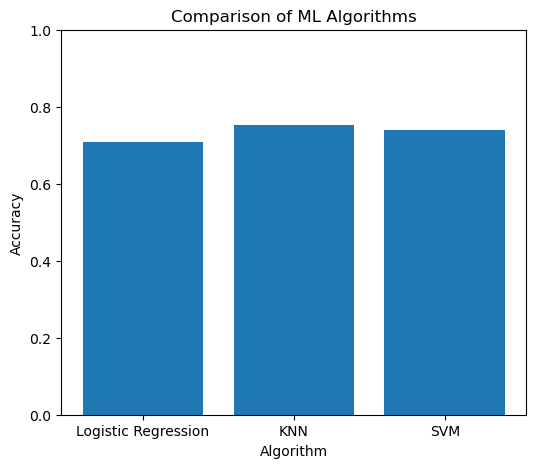

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"]
)

plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Algorithms")
plt.ylim(0, 1)

plt.show()